# ***Data Loading & Understanding***

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [2]:
df = pd.read_csv("IBM_EmpDataset.csv")

In [3]:
df.head()

,Age,Attrition_Flag,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Yes,11,3,1,0,8,0,1,6,4,0,5
1,49,0,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,No,23,4,4,1,10,3,3,10,7,1,7
2,37,1,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Yes,15,3,2,0,7,3,3,0,0,0,0
3,33,0,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Yes,11,3,3,0,8,3,3,8,7,3,0
4,27,0,No,Travel_Rarely,591,Research & Development,2,1,Medical,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,No,12,3,4,1,6,3,3,2,2,2,2


In [4]:
print("Number of Rows :", df.shape[0])
print("Number of Columns :", df.shape[1])

Number of Rows : 1470
Number of Columns : 33


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 33 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition_Flag            1470 non-null   int64 
 2   Attrition                 1470 non-null   object
 3   BusinessTravel            1470 non-null   object
 4   DailyRate                 1470 non-null   int64 
 5   Department                1470 non-null   object
 6   DistanceFromHome          1470 non-null   int64 
 7   Education                 1470 non-null   int64 
 8   EducationField            1470 non-null   object
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [6]:
df.isnull().sum()

Age                         0
Attrition_Flag              0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSinceLastPromotion     0
YearsWithCurrManager        0
dtype: int

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df["Attrition"].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

In [9]:
(df["Attrition"].value_counts(normalize=True) * 100).round(2)

Attrition
No     83.88
Yes    16.12
Name: proportion, dtype: float64

# ***Exploratory Data Analysis (EDA)***

## Section 1 : Target Variable Analysis

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_23476\1333689677.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


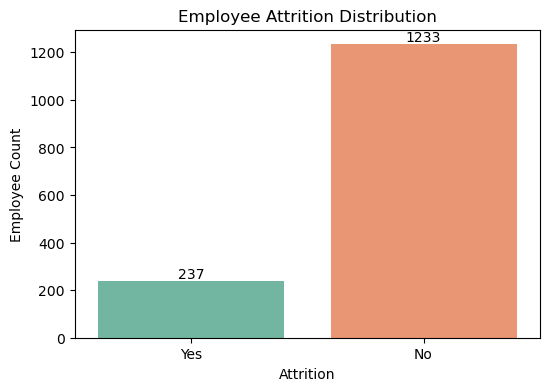

In [10]:
plt.figure(figsize=(6,4))

ax = sns.countplot(
    data=df,
    x="Attrition",
    palette="Set2"
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Employee Attrition Distribution")
plt.xlabel("Attrition")
plt.ylabel("Employee Count")

plt.show()

## Section 2 : Numerical Feature Analysis

In [11]:
continuous_features = [
    "Age",
    "DailyRate",
    "DistanceFromHome",
    "HourlyRate",
    "MonthlyIncome",
    "MonthlyRate",
    "TotalWorkingYears",
    "YearsAtCompany",
    "YearsInCurrentRole",
    "YearsSinceLastPromotion",
    "YearsWithCurrManager",
    "PercentSalaryHike"
]

ordinal_features = [
    "Education",
    "EnvironmentSatisfaction",
    "JobInvolvement",
    "JobLevel",
    "JobSatisfaction",
    "NumCompaniesWorked",
    "PerformanceRating",
    "RelationshipSatisfaction",
    "StockOptionLevel",
    "TrainingTimesLastYear",
    "WorkLifeBalance"
]

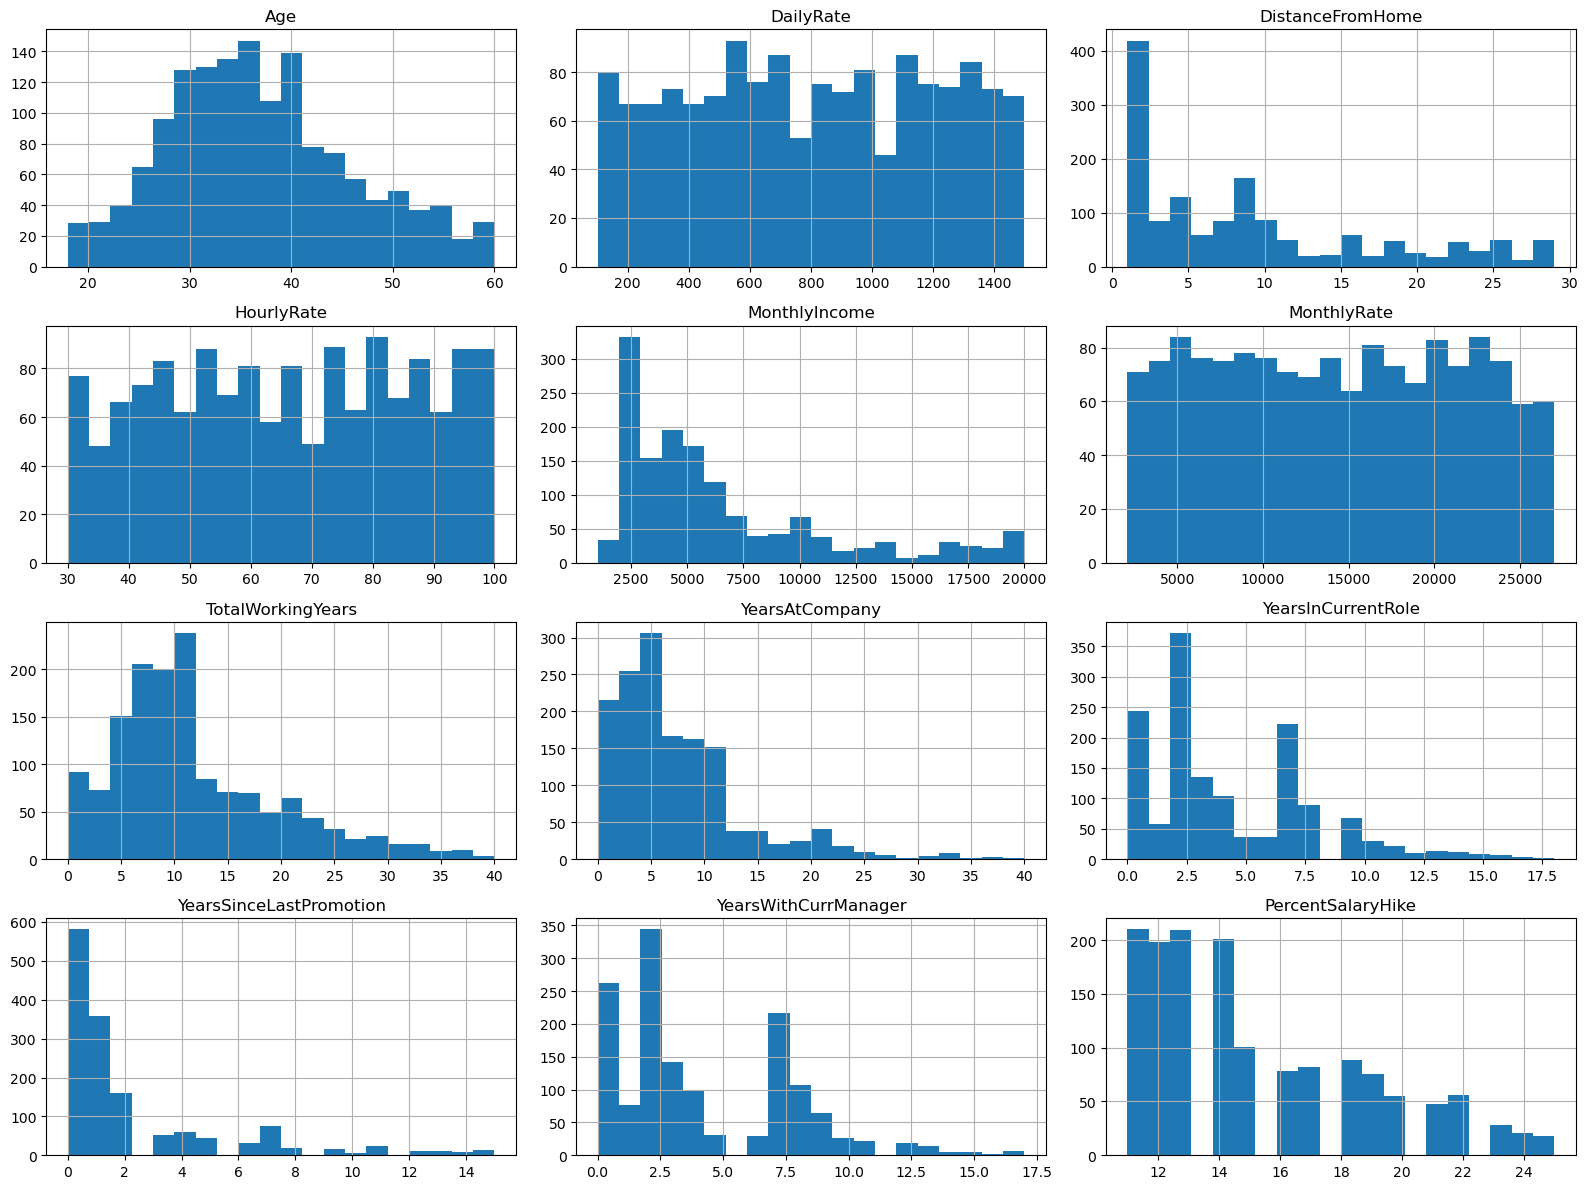

In [12]:
df[continuous_features].hist(figsize=(16,12), bins=20)
plt.tight_layout()
plt.show()

## Section 2 : Categorical Variable Analysis

In [13]:
categorical_features = [
    'BusinessTravel',
    'Department',
    'EducationField',
    'Gender',
    'JobRole',
    'MaritalStatus',
    'OverTime'
]

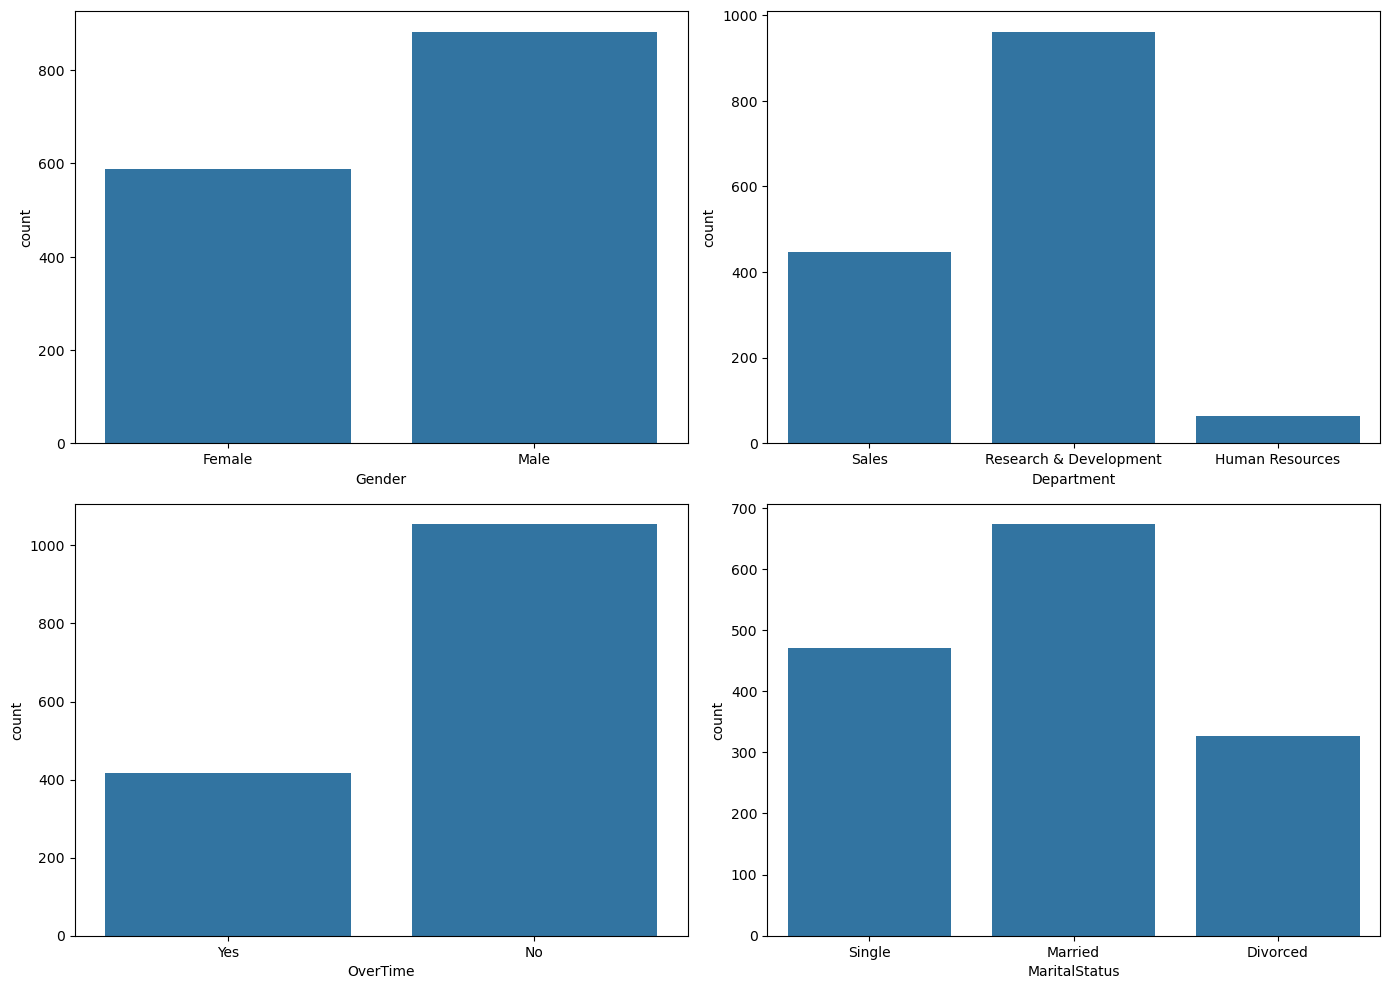

In [14]:
fig, axes = plt.subplots(2,2, figsize=(14,10))

sns.countplot(data=df,x="Gender",ax=axes[0,0])

sns.countplot(data=df,x="Department",ax=axes[0,1])

sns.countplot(data=df,x="OverTime",ax=axes[1,0])

sns.countplot(data=df,x="MaritalStatus",ax=axes[1,1])

plt.tight_layout()

# ***Bivariate Analysis***

## OverTime vs Attrition

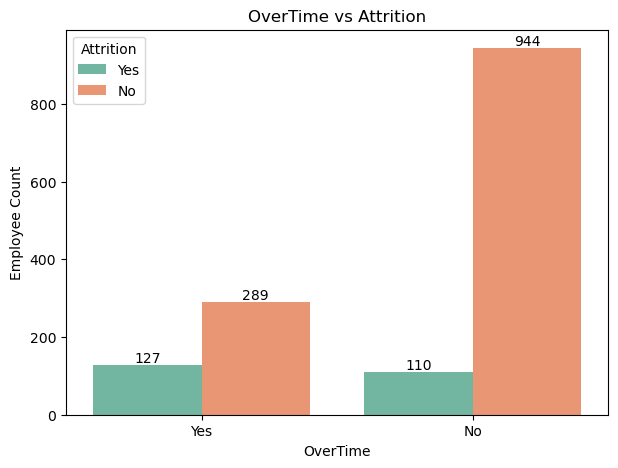

In [15]:
plt.figure(figsize=(7,5))

ax = sns.countplot(
    data=df,
    x="OverTime",
    hue="Attrition",
    palette="Set2"
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("OverTime vs Attrition")
plt.xlabel("OverTime")
plt.ylabel("Employee Count")

plt.show()

## Monthly Income vs Attrition

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_23476\1376453752.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


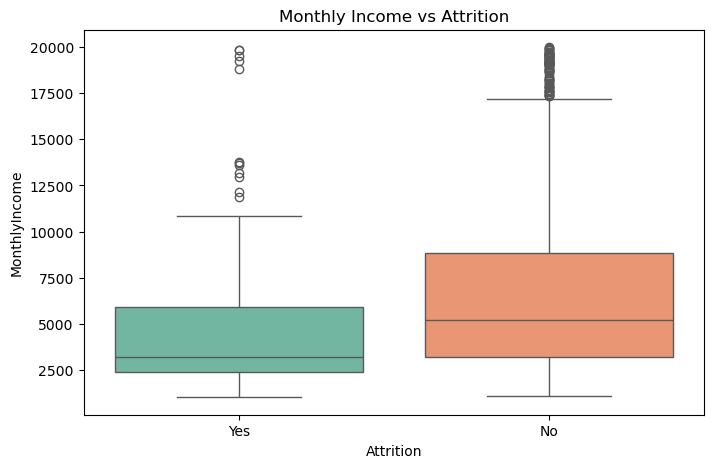

In [16]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Attrition",
    y="MonthlyIncome",
    palette="Set2"
)

plt.title("Monthly Income vs Attrition")

plt.show()

## Job Satisfaction vs Attrition

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_23476\2799347437.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


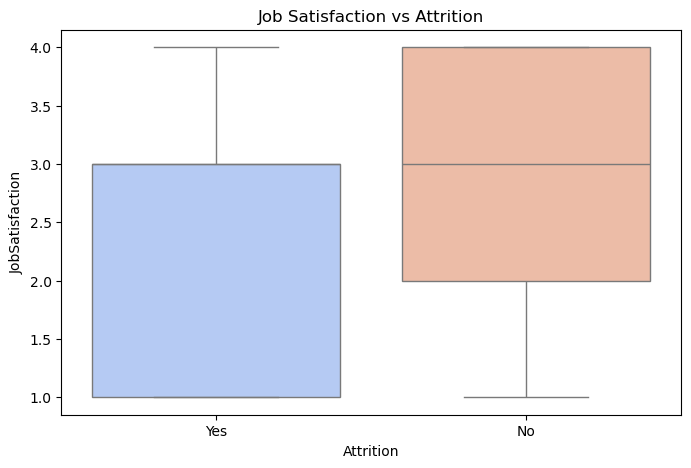

In [17]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Attrition",
    y="JobSatisfaction",
    palette="coolwarm"
)

plt.title("Job Satisfaction vs Attrition")

plt.show()

## Years at Company vs Attrition

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_23476\3500230474.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


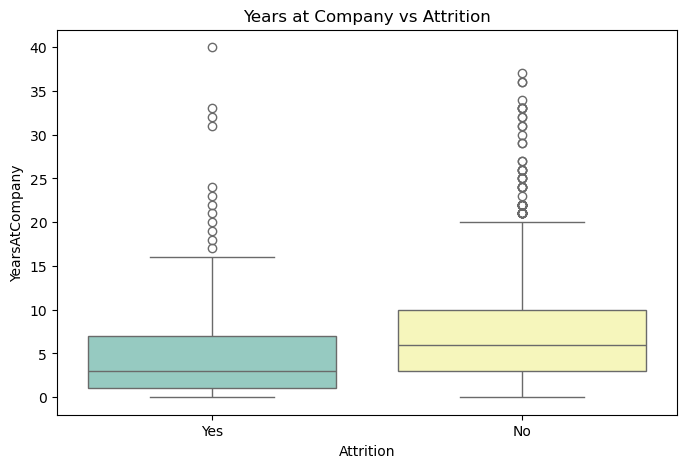

In [18]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Attrition",
    y="YearsAtCompany",
    palette="Set3"
)

plt.title("Years at Company vs Attrition")

plt.show()

## Age vs Attrition

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_23476\2398032383.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


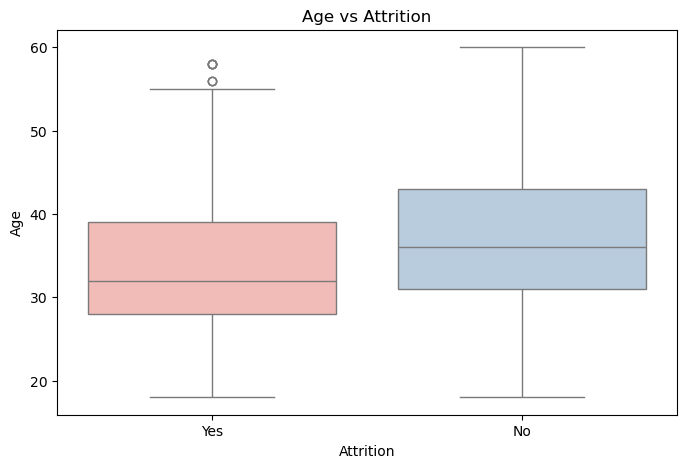

In [19]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Attrition",
    y="Age",
    palette="Pastel1"
)

plt.title("Age vs Attrition")

plt.show()

# ***Correlation Analysis***

In [20]:
correlation_matrix = df.corr(numeric_only=True)
#correlation_matrix

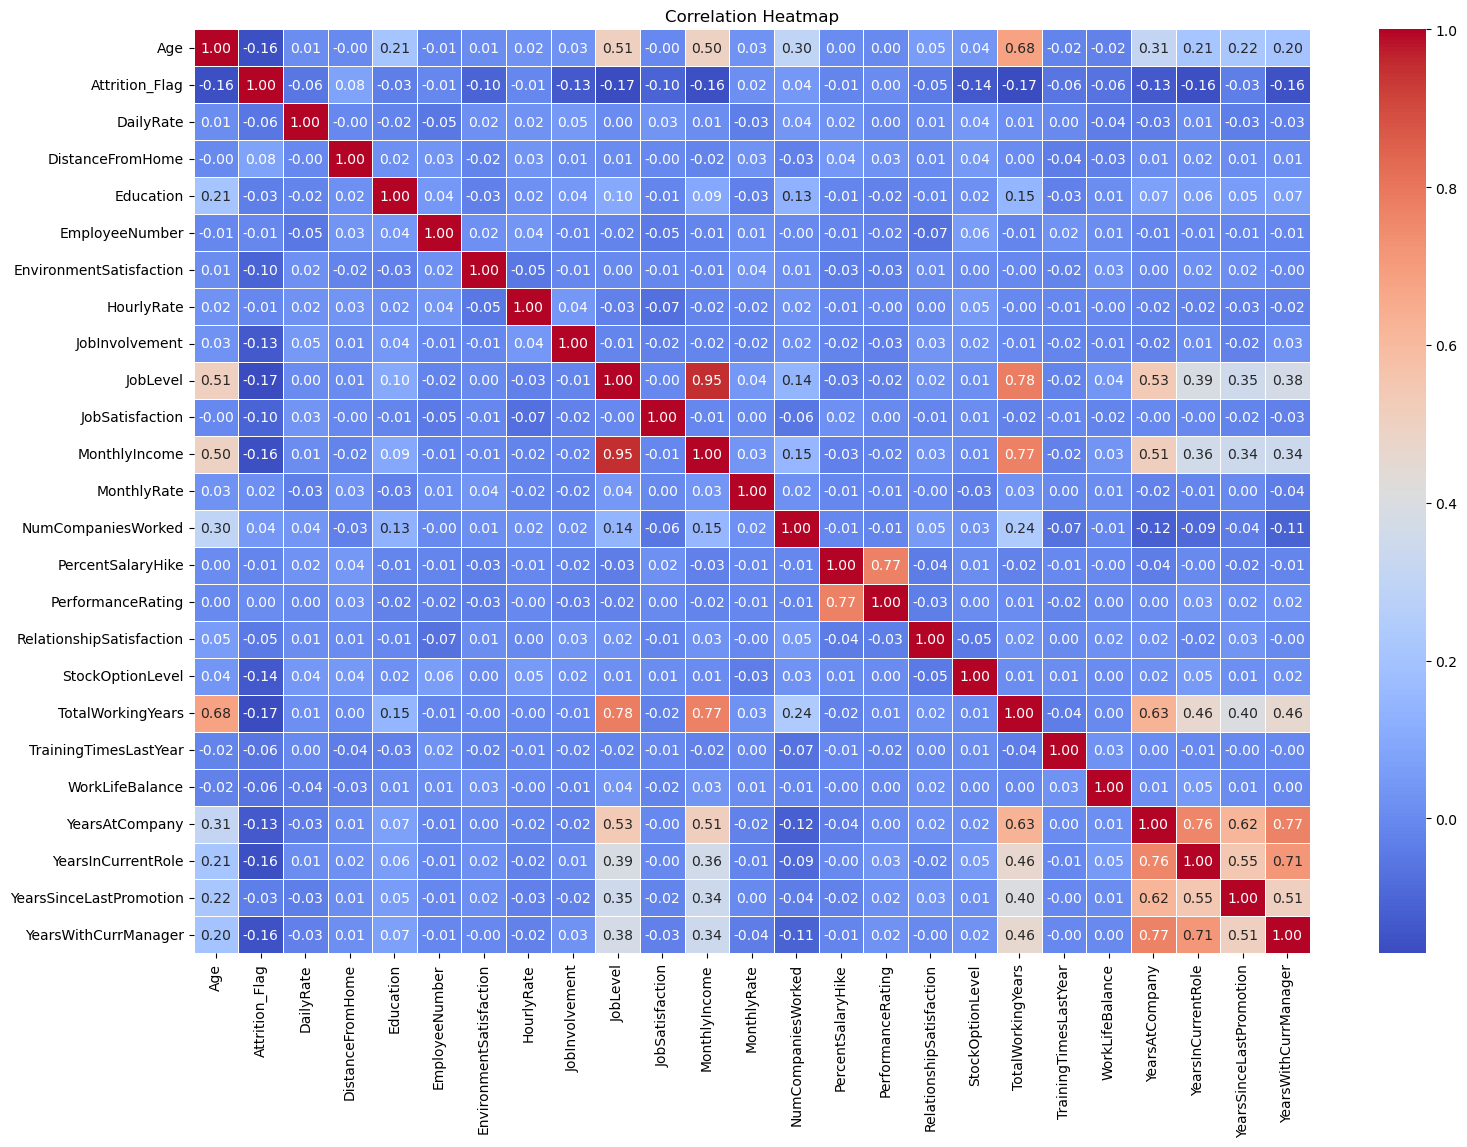

In [21]:
plt.figure(figsize=(18,12))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")

plt.show()